# The Scikit-Learn

Scikit-Learn (`sklearn`) is the core library used to build Machine Learning models in Python. 

Scikit-Learn makes Machine learning incredibly simple. Almost every single algorithm in this library follows the exact same three-step process: **Prepare Data**, **Fit** (Train), and **Predict**.

By the end of this guide, you will understand the vocabulary of AI, how to train multiple types of models, and how to save your models for real-world applications.


## Part 0: Setup

In [1]:
#installing skikit-learn
!pip install scikit-learn

#other packages used
!pip install numpy pandas matplotlib seaborn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Part 1: The Machine Learning Dictionary

Before you write any code, you must understand how an AI model looks at data. We usually split our data into two distinct parts:
* **Features ($X$):** The clues. This is a 2D table of data containing all the information the model is allowed to look at.
* **Labels ($y$):** The answers. This is a 1D list containing the exact target we want the model to learn how to predict.

Let's import our tools and create a simple dataset tracking house details.


In [2]:
import numpy as np
import pandas as pd

# Set up a small table of house data
house_data = {
    'Size_sqft': [1500, 2400, 1200, 3000, 1800, 2100, 1350, 2800],
    'Bedrooms': [3, 4, 2, 5, 3, 3, 2, 4],
    'Is_Expensive': [0, 1, 0, 1, 0, 1, 0, 1] # 0 = No, 1 = Yes
}
df = pd.DataFrame(house_data)


Now, we separate our table into our Features ($X$) and our Labels ($y$).


In [3]:
# Separate into Features (X) and Labels (y)
X = df[['Size_sqft', 'Bedrooms']]
y = df['Is_Expensive']


## Part 2: Data Splitting

**Never test an AI on the same data it used to learn.** If you do, the AI might just memorize the answers instead of actually learning the patterns, you mmay know this as __**overfitting**__.

We use `train_test_split` to securely divide our data into two groups:
* **Training Set:** The flashcards used to teach the model.
* **Testing Set:** The final exam kept hidden to grade the model later.

Let's hold back 25% of our data for the final exam.


In [4]:
from sklearn.model_selection import train_test_split

# Split data into training (7) and testing (25%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


## WARNING: 

We are about to cover multipleAI model algorithms and evaluation methodsunder various groups, however we do not cover all the algorithms and evaluation methods that are there you can look into other types through the reference provided

In [5]:
## 

In [6]:
#

## Part 3: Preprocessing (Fairness in Numbers)

Machine learning models are essentially giant math equations. They struggle when columns use vastly different number ranges. For example, a house's `Size_sqft` is in the thousands, while `Bedrooms` is a tiny number between 1 and 5. The model might falsely assume size is thousands of times more important just because the numbers are physically bigger.

We use a `StandardScaler` to shrink all columns into a fair, equal number range.


In [7]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler tool
scaler = StandardScaler()


We calculate the scaling patterns using our training clues, and then apply that scale to both sets.


In [8]:
# Learn the scale from training data and apply it
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Part 4: Classification (Predicting Categories)

Classification is the process of predicting a specific category (like guessing "Yes" or "No").

Almost every model in Scikit-Learn uses the exact same commands:
1. **`.fit()`**: Trains the model.
2. **`.predict()`**: Asks the model to guess answers.

**There are many classification algorithms to choose from.** The right one depends on your data size, complexity, and whether you need interpretability. Here are three common ones — all using the same interface:

| Algorithm | Best For |
|---|---|
| `LogisticRegression` | Simple, linearly separable data; fast and interpretable |
| `RandomForestClassifier` | Noisy or complex data; robust to outliers |
| `SVC` (Support Vector Machine) | Small-to-medium datasets; strong with clear margins |

Let's train all three on our house data to compare:

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# --- Option 1: Logistic Regression ---
# Good default for binary classification problems
clf_lr = LogisticRegression()
clf_lr.fit(X_train_scaled, y_train)

# --- Option 2: Random Forest ---
# An ensemble of many decision trees — often more accurate on messy data
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(X_train_scaled, y_train)

# --- Option 3: Support Vector Machine ---
# Finds the widest possible boundary between classes
clf_svc = SVC()
clf_svc.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Next, we give each trained model the hidden test clues and ask it to make its guesses.

In [10]:
# Generate predictions from all three models
pred_lr  = clf_lr.predict(X_test_scaled)
pred_rf  = clf_rf.predict(X_test_scaled)
pred_svc = clf_svc.predict(X_test_scaled)

Finally, we evaluate each model. **Accuracy alone can be misleading**, especially on imbalanced datasets (e.g., 95% of samples are one class — even a model that always guesses that class scores 95% accuracy!).

A better habit is to look at multiple metrics together:

| Metric | What it measures |
|---|---|
| **Accuracy** | Overall % of correct predictions |
| **Precision** | Of all *predicted* positives, how many were actually positive? |
| **Recall** | Of all *actual* positives, how many did the model catch? |
| **F1-Score** | Harmonic mean of Precision and Recall — useful when both matter |

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

models = {
    'Logistic Regression': pred_lr,
    'Random Forest':       pred_rf,
    'SVM':                 pred_svc
}

print(f"{'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} {'F1':>6}")
print("-" * 60)
for name, preds in models.items():
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec  = recall_score(y_test, preds, zero_division=0)
    f1   = f1_score(y_test, preds, zero_division=0)
    print(f"{name:<22} {acc:>10.2f} {prec:>10.2f} {rec:>8.2f} {f1:>6.2f}")

# For a full breakdown per class, use classification_report:
print("\n--- Full Report (Logistic Regression) ---")
print(classification_report(y_test, pred_lr, zero_division=0))

Model                    Accuracy  Precision   Recall     F1
------------------------------------------------------------
Logistic Regression          0.50       1.00     0.50   0.67
Random Forest                0.50       1.00     0.50   0.67
SVM                          0.50       1.00     0.50   0.67

--- Full Report (Logistic Regression) ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.50      0.67         2

    accuracy                           0.50         2
   macro avg       0.50      0.25      0.33         2
weighted avg       1.00      0.50      0.67         2



## Part 5: Regression (Predicting Continuous Numbers)

Regression is used to predict a continuous, changing numerical value (like predicting the exact dollar value of a house).

**There are many regression algorithms.** Here are three popular choices:

| Algorithm | Best For |
|---|---|
| `LinearRegression` | Simple relationships; very interpretable |
| `Ridge` | Like Linear Regression but handles multicollinearity better |
| `RandomForestRegressor` | Complex, non-linear relationships |

Let's create a new target label vector containing actual dollar prices and compare all three:

In [12]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# Create a new column of exact dollar values
y_prices = [300000, 480000, 240000, 600000, 360000, 420000, 270000, 560000]

# Split this new target data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_prices, test_size=0.25, random_state=42
)

We initialize each model, fit it, and make predictions.

In [13]:
# --- Option 1: Linear Regression ---
reg_lr = LinearRegression()
reg_lr.fit(X_train_reg, y_train_reg)
pred_lr_reg = reg_lr.predict(X_test_reg)

# --- Option 2: Ridge Regression ---
# Adds a penalty to shrink large coefficients — reduces overfitting
reg_ridge = Ridge(alpha=1.0)
reg_ridge.fit(X_train_reg, y_train_reg)
pred_ridge_reg = reg_ridge.predict(X_test_reg)

# --- Option 3: Random Forest Regressor ---
# Averages predictions from many trees — captures non-linear patterns
reg_rf = RandomForestRegressor(n_estimators=100, random_state=42)
reg_rf.fit(X_train_reg, y_train_reg)
pred_rf_reg = reg_rf.predict(X_test_reg)

**Accuracy does not apply to regression** — it only makes sense for categories.

For regression we use error-based metrics:

| Metric | What it measures |
|---|---|
| **MAE** (Mean Absolute Error) | Average absolute difference between prediction and truth — easy to interpret |
| **MSE** (Mean Squared Error) | Like MAE but penalises large errors more heavily |
| **RMSE** (Root MSE) | MSE in the same units as the target (e.g., dollars) |
| **R² Score** | How much variance the model explains (1.0 = perfect, 0.0 = no better than the mean) |

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

reg_models = {
    'Linear Regression': pred_lr_reg,
    'Ridge Regression':  pred_ridge_reg,
    'Random Forest':     pred_rf_reg,
}

print(f"{'Model':<22} {'MAE':>10} {'RMSE':>12} {'R²':>8}")
print("-" * 56)
for name, preds in reg_models.items():
    mae  = mean_absolute_error(y_test_reg, preds)
    rmse = np.sqrt(mean_squared_error(y_test_reg, preds))
    r2   = r2_score(y_test_reg, preds)
    print(f"{name:<22} ${mae:>9,.0f} ${rmse:>11,.0f} {r2:>8.3f}")

Model                         MAE         RMSE       R²
--------------------------------------------------------
Linear Regression      $        0 $          0    1.000
Ridge Regression       $        0 $          0    1.000
Random Forest          $   46,900 $     50,565   -1.841


## Part 6: How Models Think (Decision Trees)

Some models are "black boxes," meaning we don't know how they make their decisions. A **Decision Tree**, however, builds a literal, human-readable flowchart of Yes/No questions to arrive at an answer.

Let's train a Decision Tree on our original classification data to predict if a house is expensive.


In [15]:
from sklearn.tree import DecisionTreeClassifier

# max_depth stops the tree from asking too many questions and over-complicating things
tree_model = DecisionTreeClassifier(max_depth=2, random_state=42)

# Train the tree
tree_model.fit(X_train_scaled, y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

Let's create a brand new, unseen house (2500 sqft, 4 bedrooms), scale it, and see what the tree predicts.


In [16]:
new_house = pd.DataFrame({'Size_sqft': [2500], 'Bedrooms': [4]})
new_house_scaled = scaler.transform(new_house)

tree_guess = tree_model.predict(new_house_scaled)
print("Tree Prediction (1=Expensive, 0=Not):", tree_guess)


Tree Prediction (1=Expensive, 0=Not): [1]


## Part 7: Finding Hidden Patterns (Clustering)

Everything we have done so far is *Supervised Learning* (we gave the AI the answers to learn from).

**Clustering** is *Unsupervised Learning*. We don't give the model any labels ($y$). We just hand it data and ask it to discover hidden groups on its own.

**There are multiple clustering algorithms.** K-Means is the most common, but it isn't always the best choice:

| Algorithm | Best For |
|---|---|
| `KMeans` | Compact, round-ish clusters; you must specify the number of clusters |
| `DBSCAN` | Clusters of irregular shape; automatically detects outliers (noise) |
| `AgglomerativeClustering` | Hierarchical grouping; useful when you don't know the cluster count |

Let's try all three on the same shopper dataset:

In [17]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Our shopper data — no labels, just behaviour features
shopper_data = pd.DataFrame({
    'Visits_Per_Month': [1, 2, 1, 15, 20, 18, 2, 16],
    'Avg_Spend':        [15, 20, 10, 200, 250, 220, 25, 210]
})

# --- Option 1: K-Means ---
# You decide the number of clusters (k=2 here)
kmeans_model = KMeans(n_clusters=2, random_state=42, n_init='auto')
shopper_data['KMeans_Cluster'] = kmeans_model.fit_predict(shopper_data[['Visits_Per_Month', 'Avg_Spend']])

# --- Option 2: DBSCAN ---
# Groups dense regions; labels outliers as -1
dbscan_model = DBSCAN(eps=50, min_samples=2)
shopper_data['DBSCAN_Cluster'] = dbscan_model.fit_predict(shopper_data[['Visits_Per_Month', 'Avg_Spend']])

# --- Option 3: Agglomerative Clustering ---
# Builds a tree of clusters bottom-up
agg_model = AgglomerativeClustering(n_clusters=2)
shopper_data['Agg_Cluster'] = agg_model.fit_predict(shopper_data[['Visits_Per_Month', 'Avg_Spend']])

shopper_data

,Visits_Per_Month,Avg_Spend,KMeans_Cluster,DBSCAN_Cluster,Agg_Cluster
0,1,15,0,0,1
1,2,20,0,0,1
2,1,10,0,0,1
3,15,200,1,1,0
4,20,250,1,1,0
5,18,220,1,1,0
6,2,25,0,0,1
7,16,210,1,1,0


**How do we evaluate clustering without labels?** We can't use accuracy — there are no right answers.

Instead we use internal metrics that measure the quality of the groupings themselves:

| Metric | What it measures |
|---|---|
| **Silhouette Score** | How similar each point is to its own cluster vs. other clusters. Ranges from -1 to +1; higher is better |
| **Davies-Bouldin Index** | Average ratio of within-cluster scatter to between-cluster distance. Lower is better |

In [18]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

features = shopper_data[['Visits_Per_Month', 'Avg_Spend']]

cluster_results = {
    'KMeans':     shopper_data['KMeans_Cluster'],
    'DBSCAN':     shopper_data['DBSCAN_Cluster'],
    'Agglomerative': shopper_data['Agg_Cluster'],
}

print(f"{'Algorithm':<20} {'Silhouette ↑':>14} {'Davies-Bouldin ↓':>18}")
print("-" * 56)
for name, labels in cluster_results.items():
    # DBSCAN may label everything as -1 (noise) if eps is too small — guard against that
    unique = set(labels)
    if len(unique - {-1}) < 2:
        print(f"{name:<20} {'(too few clusters)':>32}")
        continue
    sil = silhouette_score(features, labels)
    db  = davies_bouldin_score(features, labels)
    print(f"{name:<20} {sil:>14.3f} {db:>18.3f}")

Algorithm              Silhouette ↑   Davies-Bouldin ↓
--------------------------------------------------------
KMeans                        0.914              0.100
DBSCAN                        0.914              0.100
Agglomerative                 0.914              0.100


## Part 8: Testing and Evaluating Your Models

Training a model is only half the job. **Evaluation** tells you whether your model actually learned something useful — or just got lucky.

This section brings together all the evaluation techniques from the earlier parts into one systematic workflow, and introduces a few additional tools every ML practitioner should know.

---

### 8a. The Problem with a Single Train/Test Split

A single split can give misleading results if you happen to get an easy (or hard) test set by chance. The standard solution is **Cross-Validation**: we split the data into *k* folds, train on *k−1* folds, test on the remaining fold, and repeat. The final score is the average across all folds.

This gives a much more reliable estimate of real-world performance.

In [21]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

# Use 5-fold cross-validation to evaluate Logistic Regression
# 'scoring' accepts any sklearn metric string
cv_scores = cross_val_score(
    LogisticRegression(), X_train_scaled, y_train,
    cv=2, scoring='accuracy'
)

print("CV Accuracy per fold:", cv_scores.round(2))
print(f"Mean: {cv_scores.mean():.2f}  |  Std Dev: {cv_scores.std():.2f}")
# A high std dev means the model is sensitive to which data it sees — a warning sign

CV Accuracy per fold: [1. 1.]
Mean: 1.00  |  Std Dev: 0.00


---

### 8b. The Confusion Matrix

Metrics like accuracy collapse all outcomes into one number. A **confusion matrix** lets you see *exactly* where the model went wrong — which true labels it confused for which predicted labels.

```
                  Predicted: No    Predicted: Yes
Actual: No      [ True Negative    False Positive ]
Actual: Yes     [ False Negative   True Positive  ]
```

* **False Positives** (FP): The model said "Yes" but it was "No". 
* **False Negatives** (FN): The model said "No" but it was "Yes".

In a fraud detection system, a False Negative (missing real fraud) is far more costly than a False Positive — so you'd prioritise **Recall**. In a spam filter, a False Positive (flagging a real email as spam) might be more annoying — so you'd prioritise **Precision**.

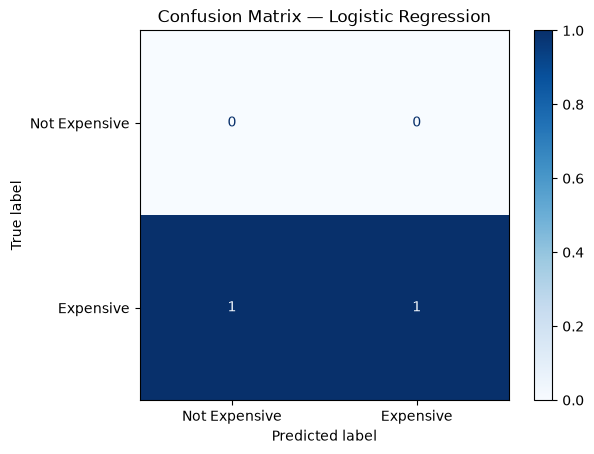

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Re-use the Logistic Regression model from Part 4
clf_lr = LogisticRegression()
clf_lr.fit(X_train_scaled, y_train)
pred_lr = clf_lr.predict(X_test_scaled)

cm = confusion_matrix(y_test, pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Expensive', 'Expensive'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression')
plt.show()

---

### 8c. Learning Curves — Diagnosing Bias vs. Variance

A **learning curve** plots training and validation accuracy as the training set grows. It tells you *why* your model is underperforming:

| Pattern | Diagnosis | Fix |
|---|---|---|
| Both curves low | High Bias (Underfitting) | Use a more complex model or add features |
| Train high, Val low | High Variance (Overfitting) | More data, regularisation, or simpler model |
| Both curves converge high | Good fit ✓ | — |

c:\Users\hutto\OneDrive\Desktop\Ashesi\FI\Intro to AI\tutorials\Python-Package-Tutorial-and-Guidebooks\PythonGuide\Lib\site-packages\sklearn\model_selection\_validation.py:2159: RuntimeWarning: Removed duplicate entries from 'train_sizes'. Number of ticks will be less than the size of 'train_sizes': 3 instead of 5.
  warnings.warn(
c:\Users\hutto\OneDrive\Desktop\Ashesi\FI\Intro to AI\tutorials\Python-Package-Tutorial-and-Guidebooks\PythonGuide\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
2 fits failed out of a total of 6.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\hutto\OneDrive\Desktop\Ashesi\FI\Intro to 

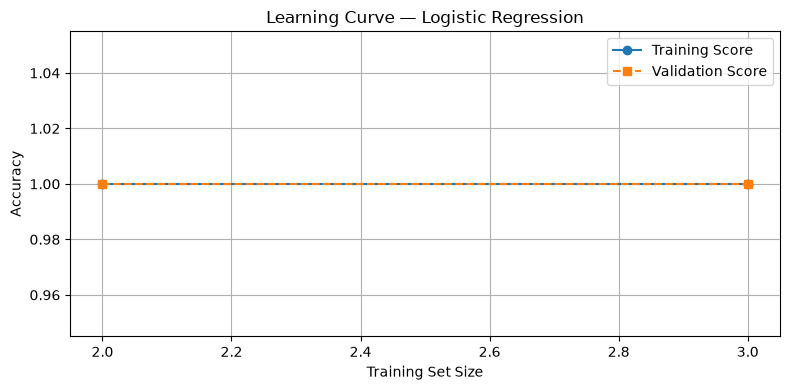

In [25]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(), X_train_scaled, y_train,
    cv=2, train_sizes=np.linspace(0.2, 1.0, 5), scoring='accuracy'
)

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training Score')
plt.plot(train_sizes, val_scores.mean(axis=1),   's--', label='Validation Score')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve — Logistic Regression')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---

### 8d. Putting It All Together — A Full Evaluation Checklist

Here is the recommended checklist every time you train a model:

1. **Cross-validate** — don't trust a single split.
2. **Check the confusion matrix** — understand *how* the model fails, not just how often.
3. **Report Precision, Recall, and F1** in addition to accuracy for classification.
4. **Use MAE, RMSE, and R²** for regression — never accuracy.
5. **Use Silhouette Score or Davies-Bouldin Index** for clustering — never accuracy.
6. **Plot a learning curve** if performance is lower than expected.
7. **Compare multiple algorithms** side-by-side before committing to one.

Below is a self-contained summary cell you can copy into any project:

=== Logistic Regression ===
Cross-Val Accuracy: 1.00 ± 0.00

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.50      0.67         2

    accuracy                           0.50         2
   macro avg       0.50      0.25      0.33         2
weighted avg       1.00      0.50      0.67         2



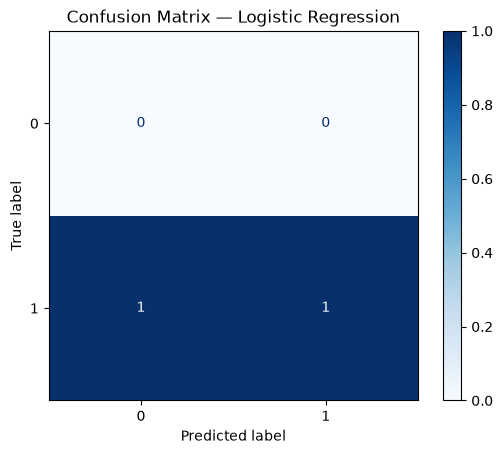

In [28]:
# ── Full Classification Evaluation Template ──────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

def evaluate_classifier(model, X_train, y_train, X_test, y_test, model_name="Model"):
    """Train, cross-validate, and fully evaluate a classifier."""
    # Cross-validation
    cv_acc = cross_val_score(model, X_train, y_train, cv=2, scoring='accuracy')
    print(f"=== {model_name} ===")
    print(f"Cross-Val Accuracy: {cv_acc.mean():.2f} ± {cv_acc.std():.2f}")

    # Final fit & test evaluation
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print("\nClassification Report:")
    print(classification_report(y_test, preds, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm).plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {model_name}')
    plt.show()

# Example usage:
evaluate_classifier(LogisticRegression(), X_train_scaled, y_train, X_test_scaled, y_test, "Logistic Regression")

## Part 9: Exporting Your Model (Saving Your Brain)

Training a model is useless if you lose it when you close your computer. You need to save your trained model so you can put it into an app, a website, or share it with a coworker.

We use a tool called `joblib` to export the model to a file.


In [29]:
import joblib

# Save the Decision Tree we trained earlier to your computer
joblib.dump(tree_model, 'my_saved_tree_model.pkl')
print("Model successfully saved!")


Model successfully saved!


Tomorrow, when you open a new script, you don't need to retrain anything. You just load the `.pkl` file and it is instantly ready to make predictions.


In [30]:
# Load the trained model back into memory
loaded_brain = joblib.load('my_saved_tree_model.pkl')

# It works perfectly without needing training data!
quick_prediction = loaded_brain.predict(new_house_scaled)
print("Loaded Model Prediction:", quick_prediction)


Loaded Model Prediction: [1]


## Part 10: The Challenge

### **The Scenario**:
You work for a bank. You have a list of customers, and you need to predict whether they will default on a loan based on their `Credit_Score` and `Debt_Ratio`.

### **The Requirements**:
1. Run the starter cell below to create the dataset.
2. Isolate the Features ($X$) and Labels ($y$).
3. Split the data into Training and Testing sets (save 25% for testing).
4. Scale your Features using `StandardScaler`.
5. Initialize a `LogisticRegression` model, `.fit()` it to your training data, and generate `.predict()` guesses on your test data.
6. Grade your model using `accuracy_score`.


In [31]:
# Challenge Starter Code - Run this cell first
loan_data = {
    'Credit_Score': [750, 600, 800, 550, 720, 590, 780, 520],
    'Debt_Ratio': [0.2, 0.6, 0.1, 0.8, 0.3, 0.7, 0.15, 0.9],
    'Will_Default': [0, 1, 0, 1, 0, 1, 0, 1] # 1 = Default, 0 = Safe
}
loan_df = pd.DataFrame(loan_data)
loan_df


,Credit_Score,Debt_Ratio,Will_Default
0,750,0.20,0
1,600,0.60,1
2,800,0.10,0
3,550,0.80,1
4,720,0.30,0
5,590,0.70,1
6,780,0.15,0
7,520,0.90,1


In [32]:
# Write your challenge solution here


## References
- [Scikit-Learn Documentation](https://scikit-learn.org/stable/documentation.html)
- [Geek4Geek -AI](https://www.geeksforgeeks.org/artificial-intelligence/artificial-intelligence/)